# EDA — Camadas N3 e N4: Corroboração de Pares e IA Generativa

Este notebook atua como Prova de Conceito (PoC) para as Camadas N3 e N4, medindo se é possível
recuperar o desmentido correspondente a um boato por similaridade textual e verificando o
comportamento da esteira diante de desinformação escrita por LLM.

**Objetivo:** Avaliar o grau de sobreposição e similaridade semântica entre notícias falsas e desmentidos legítimos correspondentes, além de inspecionar textos sintéticos gerados por IA (sinais S-11, S-13 e requisitos RF-25, RF-27).

- **Datasets analisados:** `faketrue-br`, `fakegen-br` e `portuguese-fact-checking`
- **Camadas correspondentes:** N3 (Corroboração) e N4 (Riscos / IA Generativa)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score

# Configuracoes de visualizacao
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

In [2]:
# 1. Carregamento dos dados
df_faketrue = pd.read_parquet("../datasets/faketrue-br/padronizado.parquet")
df_fakegen = pd.read_parquet("../datasets/fakegen-br/padronizado.parquet")
df_mumin = pd.read_parquet("../datasets/portuguese-fact-checking/padronizado.parquet")

print("FakeTrue.Br:", df_faketrue.shape)
print("FakeGen.BR:", df_fakegen.shape)
print("Portuguese Fact-Checking:", df_mumin.shape)

FakeTrue.Br: (3582, 10)
FakeGen.BR: (20, 10)
Portuguese Fact-Checking: (3391, 10)


In [3]:
# 2. Informacoes das amostras geradas por IA
df_fakegen.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               20 non-null     str   
 1   dataset          20 non-null     str   
 2   canal            20 non-null     str   
 3   titulo           20 non-null     str   
 4   texto            20 non-null     string
 5   rotulo           20 non-null     str   
 6   rotulo_original  20 non-null     str   
 7   data             0 non-null      object
 8   veiculo          20 non-null     str   
 9   url              0 non-null      object
dtypes: object(2), str(7), string(1)
memory usage: 61.3+ KB


### Reconstrução dos Pares Boato / Desmentido

**Pergunta arquitetural que o trecho visa responder:**
A padronização do `faketrue-br` preserva o alinhamento original entre cada boato e o desmentido que o refuta, ou o pareamento foi perdido ao virar duas linhas independentes?

In [4]:
# Na padronizacao cada par do corpus original virou duas linhas consecutivas
df_pares = df_faketrue.copy()
df_pares["par_id"] = df_pares.index // 2

df_boatos = df_pares[df_pares["rotulo"] == "falso"].reset_index(drop=True)
df_desmentidos = df_pares[df_pares["rotulo"] == "verdadeiro"].reset_index(drop=True)

print(f"Boatos (lado falso): {len(df_boatos)}")
print(f"Desmentidos (lado verdadeiro): {len(df_desmentidos)}")

# Validacao do alinhamento: cada par_id deve aparecer exatamente uma vez em cada lado
alinhado = (df_boatos["par_id"].values == df_desmentidos["par_id"].values).all()
print(f"\nAlinhamento posicional preservado: {alinhado}")

print("\nVeiculos de origem por lado do par:")
print("Lado falso:", df_boatos["veiculo"].value_counts().index.tolist())
print("Lado verdadeiro (top 3):", df_desmentidos["veiculo"].value_counts().head(3).index.tolist())

display(pd.DataFrame({
    "par_id": df_boatos["par_id"].head(3),
    "boato (inicio)": df_boatos["texto"].head(3).str[:90],
    "desmentido (inicio)": df_desmentidos["texto"].head(3).str[:90]
}))

Boatos (lado falso): 1791
Desmentidos (lado verdadeiro): 1791

Alinhamento posicional preservado: True

Veiculos de origem por lado do par:
Lado falso: ['www.boatos.org']
Lado verdadeiro (top 3): ['g1.globo.com', 'noticias.uol.com.br', 'piaui.folha.uol.com.br']


,par_id,boato (inicio),desmentido (inicio)
0,0,carnaval em olinda. arrastão monstro. fazuele isso foi só um aperitivo do que tá por vir n,circula pelas redes sociais um vídeo que mostra o expresidente luiz inácio lula da silva d
1,1,"carro alegórico da escola de samba grande rio, que homenageava o diabo pegou fogo na abert","pouco antes de a beijaflor de nilópolis entrar na sapucaí, ainda na armação, na avenida pr"
2,2,"cantor léo apoiando atos antidemocráticos. algo precisa ser feito, pessoas que motivam ess",circula nas redes sociais um vídeo que mostra o cantor leo chaves em que ele fala sobre se


**Resposta objetiva com base nos dados obtidos:**
O alinhamento posicional se manteve intacto: 1.791 boatos e 1.791 desmentidos em linhas consecutivas, recuperáveis por `index // 2`. Isso libera a arquitetura de reprocessar o CSV original — o `padronizado.parquet` já serve de conjunto de referência (*ground truth*) para avaliar o recuperador da Camada N3, pois para cada boato sabemos exatamente qual documento deveria ser devolvido.

### Deduplicação do Índice de Corroboração

**Pergunta arquitetural que o trecho visa responder:**
Quantos documentos distintos o índice de busca da N3 realmente contém, uma vez que o mesmo desmentido pode refutar vários boatos diferentes?

In [5]:
# Um mesmo desmentido do G1 Fato ou Fake pode cobrir varios boatos derivados
reuso = df_desmentidos["url"].value_counts()

print(f"Linhas no lado verdadeiro: {len(df_desmentidos)}")
print(f"URLs distintas (documentos reais): {df_desmentidos['url'].nunique()}")
print(f"Taxa de redundancia: {(1 - df_desmentidos['url'].nunique() / len(df_desmentidos)) * 100:.1f}%")
print(f"Desmentidos que cobrem mais de um boato: {(reuso > 1).sum()}")
print(f"Maior reuso observado: {reuso.max()} boatos refutados pelo mesmo texto")

print("\nDesmentido mais reaproveitado:")
print(reuso.index[0])

# Indice de corroboracao deduplicado (o que a N3 de fato indexaria)
df_indice = df_desmentidos.drop_duplicates(subset="url").reset_index(drop=True)
mapa_url = {u: i for i, u in enumerate(df_indice["url"])}
gabarito = df_desmentidos["url"].map(mapa_url).values

print(f"\nTamanho do indice deduplicado: {len(df_indice)} documentos")

Linhas no lado verdadeiro: 1791
URLs distintas (documentos reais): 1344
Taxa de redundancia: 25.0%
Desmentidos que cobrem mais de um boato: 277
Maior reuso observado: 12 boatos refutados pelo mesmo texto

Desmentido mais reaproveitado:
https://g1.globo.com/fato-ou-fake/noticia/2021/08/17/e-fake-que-lula-foi-recebido-aos-gritos-de-ladrao-por-multidao-ao-desembarcar-em-pernambuco.ghtml

Tamanho do indice deduplicado: 1344 documentos


**Resposta objetiva com base nos dados obtidos:**
Das 1.791 linhas do lado verdadeiro sobram apenas 1.344 documentos distintos — 25% de redundância, com um único desmentido do *Fato ou Fake* refutando 12 boatos diferentes. Essa é a estrutura real do problema: a desinformação se reescreve em várias versões em torno de uma mesma alegação, enquanto o desmentido é único. A arquitetura ganha com isso, porque o índice da N3 é muito menor do que o volume de boatos que precisa atender, e reforça o RF-11 (reaproveitar checagens já feitas). A partir daqui todas as métricas usam o índice deduplicado, para não inflar o acerto contando duplicatas como acertos distintos.

### Separabilidade da Similaridade Léxica

**Pergunta arquitetural que o trecho visa responder:**
A similaridade de cosseno sobre TF-IDF distingue o par verdadeiro (boato e seu desmentido) de um par aleatório, ou o vocabulário jornalístico compartilhado achata a diferença?

In [6]:
# Vetorizador ajustado sobre os dois lados, para haver vocabulario comum
vetorizador_n3 = TfidfVectorizer(
    max_features=40000,
    sublinear_tf=True,
    strip_accents="unicode"
)
vetorizador_n3.fit(pd.concat([df_boatos["texto"], df_indice["texto"]]))

M_boatos = vetorizador_n3.transform(df_boatos["texto"])
M_indice = vetorizador_n3.transform(df_indice["texto"])

# Matriz 1791 x 1344 de similaridades boato -> documento do indice
S = cosine_similarity(M_boatos, M_indice)
print("Matriz de similaridade:", S.shape)

# Positivos: o desmentido correto. Negativos: um documento sorteado do indice
sim_par_real = S[np.arange(len(df_boatos)), gabarito]
rng = np.random.default_rng(42)
sim_par_aleatorio = S[np.arange(len(df_boatos)), rng.integers(0, len(df_indice), len(df_boatos))]

print(f"\nPar real      -> media {sim_par_real.mean():.3f} | mediana {np.median(sim_par_real):.3f}")
print(f"Par aleatorio -> media {sim_par_aleatorio.mean():.3f} | mediana {np.median(sim_par_aleatorio):.3f}")

auc = roc_auc_score(
    np.r_[np.ones_like(sim_par_real), np.zeros_like(sim_par_aleatorio)],
    np.r_[sim_par_real, sim_par_aleatorio]
)
print(f"AUC (par real vs par aleatorio): {auc:.3f}")

Matriz de similaridade: (1791, 1344)

Par real      -> media 0.227 | mediana 0.187
Par aleatorio -> media 0.036 | mediana 0.033
AUC (par real vs par aleatorio): 0.982


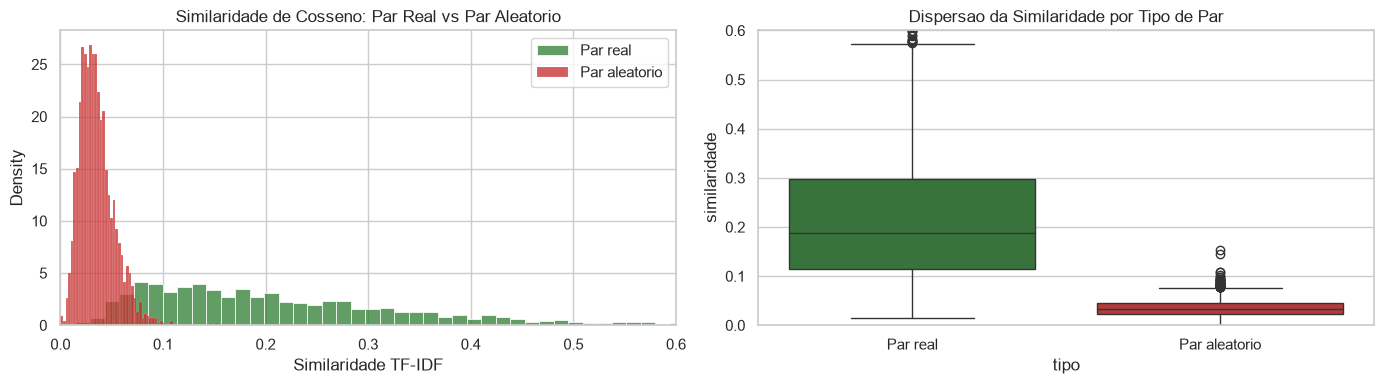

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(sim_par_real, bins=60, color="#2e7d32", label="Par real", stat="density", ax=axes[0])
sns.histplot(sim_par_aleatorio, bins=60, color="#c62828", label="Par aleatorio", stat="density", ax=axes[0])
axes[0].set_title("Similaridade de Cosseno: Par Real vs Par Aleatorio")
axes[0].set_xlabel("Similaridade TF-IDF")
axes[0].set_xlim(0, 0.6)
axes[0].legend()

df_box = pd.DataFrame({
    "similaridade": np.r_[sim_par_real, sim_par_aleatorio],
    "tipo": ["Par real"] * len(sim_par_real) + ["Par aleatorio"] * len(sim_par_aleatorio)
})
sns.boxplot(data=df_box, x="tipo", y="similaridade", hue="tipo", legend=False,
            palette=["#2e7d32", "#c62828"], ax=axes[1])
axes[1].set_title("Dispersao da Similaridade por Tipo de Par")
axes[1].set_ylim(0, 0.6)

plt.tight_layout()
plt.show()

**Resposta objetiva com base nos dados obtidos:**
O par real tem similaridade média de 0,227 contra 0,036 do par aleatório, com AUC de 0,982 — as distribuições quase não se tocam. A limitação evidente é o valor absoluto baixo: mesmo o par correto fica na casa de 0,2, porque o boato usa vocabulário coloquial de rede social e o desmentido usa vocabulário jornalístico. Isso modela a arquitetura de duas formas: o limiar de similaridade da N3 não pode ser calibrado por intuição (0,2 já é um sinal forte, não fraco), e há espaço claro para *embeddings* semânticos elevarem esse patamar, já que o TF-IDF só captura a interseção literal de palavras.

### Viabilidade do Recuperador de Corroboração (RF-27)

**Pergunta arquitetural que o trecho visa responder:**
Um recuperador puramente léxico sobre CPU já devolve o desmentido correto entre os primeiros resultados, ou a Camada N3 exige desde o início uma base vetorial com *embeddings*?

In [8]:
# Ranqueamento completo: para cada boato, ordenar os 1344 documentos do indice
ordenacao = np.argsort(-S, axis=1)
posicoes = np.array([np.where(ordenacao[i] == gabarito[i])[0][0] for i in range(len(df_boatos))])

resultados_recall = {}
for k in (1, 3, 5, 10, 20):
    resultados_recall[k] = (posicoes < k).mean()
    print(f"Recall@{k:<2} = {resultados_recall[k]:.3f}")

mrr = (1 / (posicoes + 1)).mean()
print(f"\nMRR (Mean Reciprocal Rank): {mrr:.3f}")
print(f"Posicao mediana do desmentido correto: {int(np.median(posicoes)) + 1}o lugar")

Recall@1  = 0.630
Recall@3  = 0.768
Recall@5  = 0.813
Recall@10 = 0.859
Recall@20 = 0.891

MRR (Mean Reciprocal Rank): 0.714
Posicao mediana do desmentido correto: 1o lugar


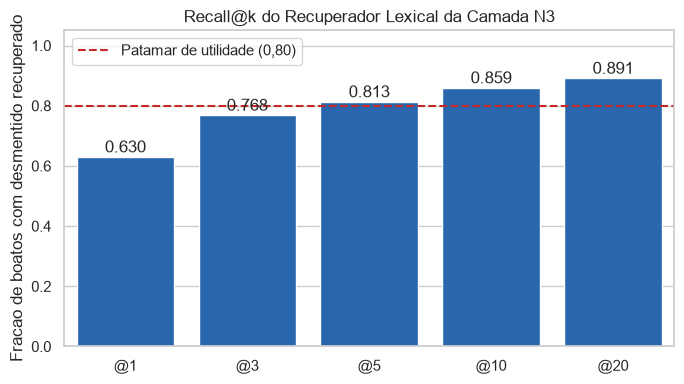

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ks = list(resultados_recall.keys())
valores = [resultados_recall[k] for k in ks]

sns.barplot(x=[f"@{k}" for k in ks], y=valores, color="#1565c0", ax=ax)
ax.axhline(0.80, color="#c62828", linestyle="--", label="Patamar de utilidade (0,80)")
for i, v in enumerate(valores):
    ax.text(i, v + 0.015, f"{v:.3f}", ha="center")
ax.set_title("Recall@k do Recuperador Lexical da Camada N3")
ax.set_ylabel("Fracao de boatos com desmentido recuperado")
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.show()

**Resposta objetiva com base nos dados obtidos:**
O recuperador léxico coloca o desmentido correto em primeiro lugar em 63% dos casos e entre os cinco primeiros em 81,3%, com MRR de 0,714 — sem GPU, sem API e sem custo de token. Isso define a esteira da N3: buscar candidatos com TF-IDF/BM25 e entregar apenas o *top-5* para a N4 avaliar por NLI, o que reduz em duas ordens de grandeza o volume enviado ao LLM. A limitação é o teto: 18,7% dos boatos não têm o desmentido nem entre os cinco primeiros, e esse resíduo é exatamente o caso em que o boato foi reescrito sem reaproveitar palavras da notícia original — o caso que só *embeddings* semânticos resolvem. O recuperador léxico serve de primeiro estágio, não de estágio único.

### Calibração do Limiar de Corroboração (S-11)

**Pergunta arquitetural que o trecho visa responder:**
Qual limiar de similaridade a N3 deve adotar para declarar que encontrou corroboração, considerando que um falso alarme aqui contamina o score S-11 com evidência irrelevante?

,limiar,recall (acha o par real),falso alarme (aceita par aleatorio)
0,0.050,0.9726,0.1798
1,0.075,0.8950,0.0240
2,0.100,0.7940,0.0028
3,0.125,0.7085,0.0011
4,0.150,0.6175,0.0006
5,0.200,0.4651,0.0000
6,0.250,0.3462,0.0000


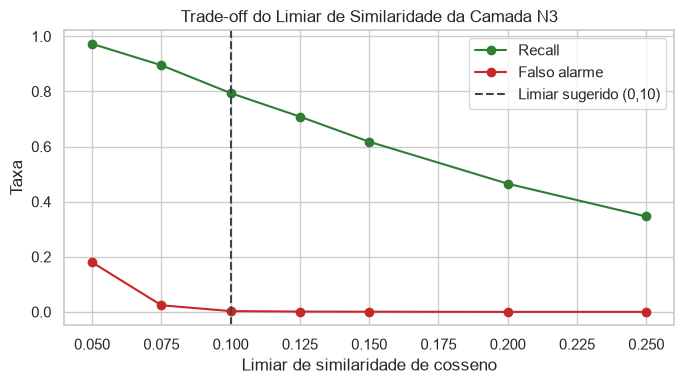

In [10]:
linhas = []
for limiar in (0.05, 0.075, 0.10, 0.125, 0.15, 0.20, 0.25):
    linhas.append({
        "limiar": limiar,
        "recall (acha o par real)": (sim_par_real >= limiar).mean(),
        "falso alarme (aceita par aleatorio)": (sim_par_aleatorio >= limiar).mean()
    })

df_limiares = pd.DataFrame(linhas)
display(df_limiares.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_limiares["limiar"], df_limiares["recall (acha o par real)"],
        marker="o", color="#2e7d32", label="Recall")
ax.plot(df_limiares["limiar"], df_limiares["falso alarme (aceita par aleatorio)"],
        marker="o", color="#c62828", label="Falso alarme")
ax.axvline(0.10, color="#37474f", linestyle="--", label="Limiar sugerido (0,10)")
ax.set_title("Trade-off do Limiar de Similaridade da Camada N3")
ax.set_xlabel("Limiar de similaridade de cosseno")
ax.set_ylabel("Taxa")
ax.legend()

plt.tight_layout()
plt.show()

**Resposta objetiva com base nos dados obtidos:**
O limiar de 0,10 é o ponto de operação: recupera 79,4% dos pares reais com apenas 0,6% de falso alarme. Descer para 0,05 sobe o recall para 97,3%, mas o falso alarme explode para 18,0% — quase um em cada cinco documentos irrelevantes seria tratado como corroboração. Isso tem consequência direta no produto: como o S-11 pesa 15 pontos na Dimensão de Corroboração, aceitar evidência irrelevante produziria justificativas incoerentes na interface, com a Vera citando um link que não fala do assunto. A arquitetura deve então operar em 0,10 e tratar a ausência de corroboração como gatilho de escalada para a N4, não como prova de falsidade.

### Limite do Dataset para Escalar o S-11

**Pergunta arquitetural que o trecho visa responder:**
O `faketrue-br` permite validar a escala completa do sinal S-11 (0, 1, 2 ou 3+ veículos confiáveis publicando o mesmo fato)?

In [11]:
print("Distribuicao de veiculos no lado verdadeiro (%):")
print((df_desmentidos["veiculo"].value_counts(normalize=True) * 100).head(6).round(1))
print(f"\nDominios distintos no lado verdadeiro: {df_desmentidos['veiculo'].nunique()}")

# Quantos veiculos distintos corroboram cada boato
veiculos_por_boato = df_desmentidos.groupby(df_boatos["par_id"])["veiculo"].nunique()
print("\nVeiculos distintos por boato:")
print(veiculos_por_boato.value_counts())

print("\nCobertura da escala do S-11 pelo dataset:")
for faixa, s in [("0 veiculos", 0.0), ("1 veiculo", 0.5), ("2 veiculos", 0.8), ("3+ veiculos", 1.0)]:
    coberto = "sim" if faixa == "1 veiculo" else "nao"
    print(f"  {faixa:<12} (s = {s}) -> presente no dataset: {coberto}")

Distribuicao de veiculos no lado verdadeiro (%):
veiculo
g1.globo.com              85.6
noticias.uol.com.br        4.3
piaui.folha.uol.com.br     3.6
www1.folha.uol.com.br      2.1
www.uol.com.br             1.7
economia.uol.com.br        0.4
Name: proportion, dtype: float64

Dominios distintos no lado verdadeiro: 32

Veiculos distintos por boato:
veiculo
1    1791
Name: count, dtype: int64

Cobertura da escala do S-11 pelo dataset:
  0 veiculos   (s = 0.0) -> presente no dataset: nao
  1 veiculo    (s = 0.5) -> presente no dataset: sim
  2 veiculos   (s = 0.8) -> presente no dataset: nao
  3+ veiculos  (s = 1.0) -> presente no dataset: nao


**Resposta objetiva com base nos dados obtidos:**
O dataset é estruturalmente 1:1 — cada boato tem exatamente um desmentido, e 85,6% deles vêm do `g1.globo.com`. Só o degrau "1 veículo" (s = 0,5) da escala do S-11 pode ser exercitado aqui; os degraus de 2 e 3+ veículos não têm suporte nos dados. Isso é uma limitação de avaliação, não de arquitetura: a contagem de veículos do RF-28 só poderá ser validada em produção, contra APIs de busca e RSS ao vivo. Para a PoC, a consequência é que o `faketrue-br` valida a **recuperação** (RF-27) com rigor, mas não a **contagem** (RF-28), e a concentração em um único veículo ainda embute o risco de o modelo aprender o estilo editorial do G1 em vez do conceito de corroboração.

### Reaproveitamento de Checagens e Originalidade (RF-11 e S-13)

**Pergunta arquitetural que o trecho visa responder:**
Com que frequência a mesma alegação reaparece reescrita em rede social, isto é, qual o ganho real de manter um cache de checagens e um detector de quase-duplicatas?

In [12]:
print("Composicao do portuguese-fact-checking:")
display(df_mumin.groupby(["veiculo", "rotulo"]).size().unstack(fill_value=0))

print(f"Tamanho mediano dos posts: {int(df_mumin['texto'].str.split().apply(len).median())} palavras")

# Similaridade de cada post contra todos os outros do corpus
vetorizador_dup = TfidfVectorizer(max_features=40000, sublinear_tf=True, strip_accents="unicode")
M_posts = vetorizador_dup.fit_transform(df_mumin["texto"])

S_posts = cosine_similarity(M_posts)
np.fill_diagonal(S_posts, 0)
vizinho_mais_proximo = S_posts.max(axis=1)

linhas_dup = []
for limiar in (0.5, 0.7, 0.8, 0.9):
    linhas_dup.append({
        "limiar": limiar,
        "posts com quase-duplicata": int((vizinho_mais_proximo >= limiar).sum()),
        "percentual": (vizinho_mais_proximo >= limiar).mean() * 100
    })

df_dup = pd.DataFrame(linhas_dup)
display(df_dup.round(1))

Composicao do portuguese-fact-checking:


rotulo,falso,verdadeiro
veiculo,,
COVID19.BR,864,1123
MuMiN-PT,1343,61


Tamanho mediano dos posts: 22 palavras


,limiar,posts com quase-duplicata,percentual
0,0.5,841,24.8
1,0.7,592,17.5
2,0.8,506,14.9
3,0.9,374,11.0


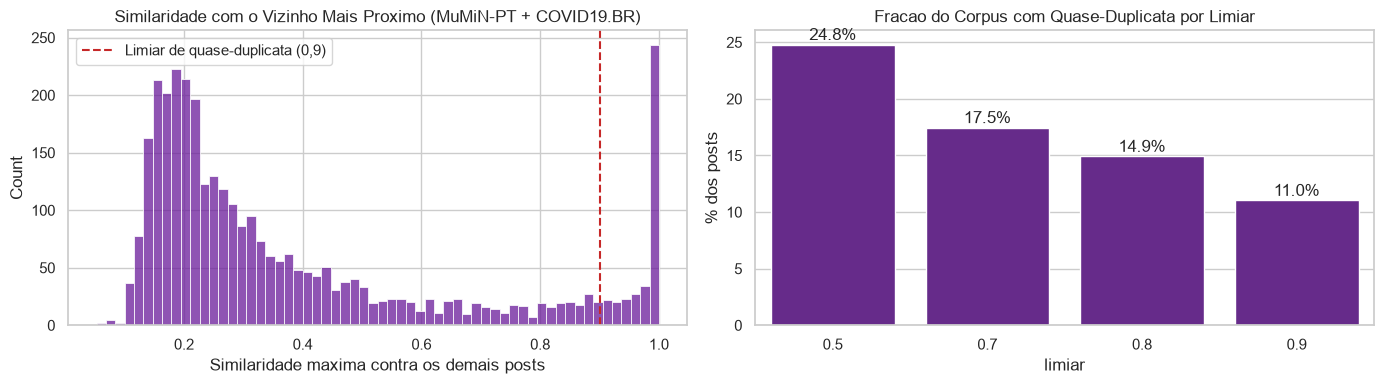

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(vizinho_mais_proximo, bins=60, color="#6a1b9a", ax=axes[0])
axes[0].axvline(0.9, color="#c62828", linestyle="--", label="Limiar de quase-duplicata (0,9)")
axes[0].set_title("Similaridade com o Vizinho Mais Proximo (MuMiN-PT + COVID19.BR)")
axes[0].set_xlabel("Similaridade maxima contra os demais posts")
axes[0].legend()

sns.barplot(data=df_dup, x="limiar", y="percentual", color="#6a1b9a", ax=axes[1])
for i, v in enumerate(df_dup["percentual"]):
    axes[1].text(i, v + 0.4, f"{v:.1f}%", ha="center")
axes[1].set_title("Fracao do Corpus com Quase-Duplicata por Limiar")
axes[1].set_ylabel("% dos posts")

plt.tight_layout()
plt.show()

**Resposta objetiva com base nos dados obtidos:**
11% dos posts têm uma quase-duplicata acima de 0,9 e 24,8% acima de 0,5, num corpus de textos curtos (mediana de 22 palavras). Isso quantifica o ganho do cache do RF-11: aproximadamente uma em cada dez consultas pode ser respondida por uma checagem já existente, sem gastar nada de LLM. Para o S-13 (originalidade), a faixa entre 0,5 e 0,9 é a mais reveladora — é o texto copiado e **alterado**, que o sinal deve punir, e distingui-lo da replicação fiel exige comparar fatos, não palavras, o que joga a decisão final para a N4. A limitação é o desbalanceamento extremo do MuMiN-PT (1.343 falsos contra 61 verdadeiros), que impede usar este corpus para medir desempenho de classificação: ele serve para medir recirculação, não acurácia.

### Perfil Estilométrico do Texto Gerado por IA (RF-25 e S-10)

**Pergunta arquitetural que o trecho visa responder:**
Desinformação escrita por LLM carrega as marcas estilísticas que a Camada N2 aprendeu a detectar (CAIXA ALTA, pontuação expressiva, apelo de urgência)?

In [14]:
def extrair_metricas_estilo_n4(serie):
    s = serie.fillna("").astype(str)
    letras = s.apply(lambda t: [c for c in t if c.isalpha()])
    return pd.DataFrame({
        "n_palavras": s.str.split().apply(len),
        "taxa_maiusculas": [sum(c.isupper() for c in L) / len(L) if L else 0.0 for L in letras],
        "qtd_exclamacoes": s.str.count("!"),
        "diversidade_lexical": s.apply(lambda t: len(set(t.lower().split())) / max(len(t.split()), 1))
    })

grupos = {
    "IA generativa (fakegen)": df_fakegen["texto"],
    "Fake humano (faketrue)": df_boatos["texto"],
    "Verdadeiro (faketrue)": df_indice["texto"]
}

df_comparativo = pd.DataFrame({nome: extrair_metricas_estilo_n4(serie).mean()
                               for nome, serie in grupos.items()})
print("Media das metricas de estilo por grupo:")
display(df_comparativo.round(3))

print("\nExemplo de titulo gerado por IA:")
print(df_fakegen["titulo"].iloc[0])

Media das metricas de estilo por grupo:


,IA generativa (fakegen),Fake humano (faketrue),Verdadeiro (faketrue)
n_palavras,379.000,143.863,517.530
taxa_maiusculas,0.025,0.000,0.009
qtd_exclamacoes,0.250,1.911,0.418
diversidade_lexical,0.648,0.720,0.571



Exemplo de titulo gerado por IA:
Escândalo Explosivo: Petrobras teria financiado campanha presidencial em troca de contratos superfaturados na Repar, denunciam delatores da Odebrecht


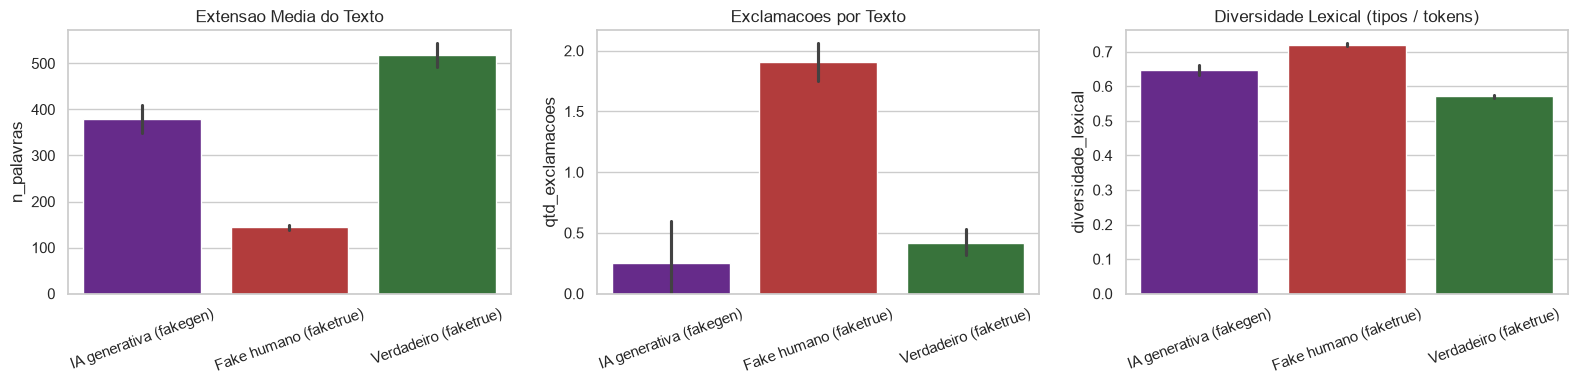

In [15]:
df_estilo_n4 = pd.concat([
    extrair_metricas_estilo_n4(serie).assign(grupo=nome)
    for nome, serie in grupos.items()
], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
paleta = ["#6a1b9a", "#c62828", "#2e7d32"]

sns.barplot(data=df_estilo_n4, x="grupo", y="n_palavras", hue="grupo", legend=False,
            palette=paleta, ax=axes[0])
axes[0].set_title("Extensao Media do Texto")

sns.barplot(data=df_estilo_n4, x="grupo", y="qtd_exclamacoes", hue="grupo", legend=False,
            palette=paleta, ax=axes[1])
axes[1].set_title("Exclamacoes por Texto")

sns.barplot(data=df_estilo_n4, x="grupo", y="diversidade_lexical", hue="grupo", legend=False,
            palette=paleta, ax=axes[2])
axes[2].set_title("Diversidade Lexical (tipos / tokens)")

for ax in axes:
    ax.tick_params(axis="x", rotation=20)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

**Resposta objetiva com base nos dados obtidos:**
O texto de LLM não reproduz o estilo do boato humano: usa 0,25 exclamação por texto contra 1,91 do fake humano, e tem extensão (379 palavras) intermediária entre o boato curto (144) e a notícia real (518). Ou seja, ele imita a **forma** do jornalismo sem os gatilhos de sensacionalismo. Uma ressalva metodológica importante: os textos do `faketrue-br` vêm minusculados na origem (taxa de maiúsculas 0,000 no lado falso), então a comparação de CAIXA ALTA não é válida aqui e foi descartada da leitura. A consequência arquitetural é que o S-10 (probabilidade de texto gerado por IA) merece mesmo o peso baixo de 2 pontos: o que muda com a IA generativa não é um sinal novo a detectar, é a **perda de poder** dos sinais de estilo da N2.

### Teste de Estresse do Classificador N2 contra LLM

**Pergunta arquitetural que o trecho visa responder:**
O classificador da Camada N2, treinado e validado em boato humano, sobrevive à desinformação gerada por IA, ou existe um caminho em que a esteira falha sem a N4?

In [16]:
modelo_n2 = joblib.load("../vera/models/classificador_n2.joblib")

# Referencia: desempenho sobre boato humano (todos os 1791 sao falsos)
pred_humano = modelo_n2.predict(df_boatos["texto"])
acerto_humano = (pred_humano == "falso").mean()

# Alvo do teste: os 20 sinteticos do FakeGen.BR (todos rotulados como falsos)
pred_ia = modelo_n2.predict(df_fakegen["texto"])
proba_ia = modelo_n2.predict_proba(df_fakegen["texto"])
acerto_ia = (pred_ia == "falso").mean()

print(f"N2 sobre 1791 boatos humanos  -> detecta como falso: {acerto_humano * 100:.1f}%")
print(f"N2 sobre 20 textos de LLM     -> detecta como falso: {acerto_ia * 100:.1f}%")
print(f"\nQueda de deteccao: {(acerto_humano - acerto_ia) * 100:.1f} pontos percentuais")

print(f"\nP(falso) media nos textos de LLM: {proba_ia[:, 0].mean():.3f}")
print("Vereditos da N2 nos sinteticos:", pd.Series(pred_ia).value_counts().to_dict())

df_escape = pd.DataFrame({
    "titulo": df_fakegen["titulo"].str[:70],
    "veredito_n2": pred_ia,
    "p_falso": proba_ia[:, 0].round(3)
}).sort_values("p_falso")

print("\nTextos falsos que a N2 considerou mais verdadeiros:")
display(df_escape.head(5))

N2 sobre 1791 boatos humanos  -> detecta como falso: 96.0%
N2 sobre 20 textos de LLM     -> detecta como falso: 40.0%

Queda de deteccao: 56.0 pontos percentuais

P(falso) media nos textos de LLM: 0.418
Vereditos da N2 nos sinteticos: {'verdadeiro': 12, 'falso': 8}

Textos falsos que a N2 considerou mais verdadeiros:


,titulo,veredito_n2,p_falso
5,"Em uma surpreendente e inédita decisão, o Tribunal Regional Federal da",verdadeiro,0.095
6,"Segunda-feira, 30 de outubro. Bom dia! Aqui estão as principais notíci",verdadeiro,0.123
4,Congresso aprova fundo secreto de R$ 10 bilhões para campanhas polític,verdadeiro,0.162
15,Secretaria de Estado da Fazenda anuncia redução drástica e inédita na,verdadeiro,0.199
11,Supremo Tribunal Federal libera espionagem global no WhatsApp para com,verdadeiro,0.216


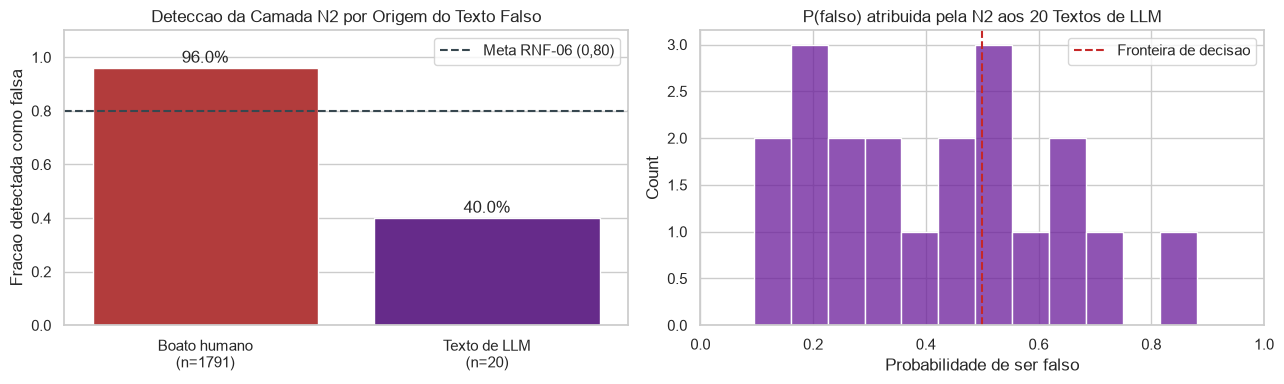

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(x=["Boato humano\n(n=1791)", "Texto de LLM\n(n=20)"],
            y=[acerto_humano, acerto_ia],
            hue=["Boato humano", "Texto de LLM"], legend=False,
            palette=["#c62828", "#6a1b9a"], ax=axes[0])
axes[0].axhline(0.80, color="#37474f", linestyle="--", label="Meta RNF-06 (0,80)")
for i, v in enumerate([acerto_humano, acerto_ia]):
    axes[0].text(i, v + 0.02, f"{v * 100:.1f}%", ha="center")
axes[0].set_title("Deteccao da Camada N2 por Origem do Texto Falso")
axes[0].set_ylabel("Fracao detectada como falsa")
axes[0].set_ylim(0, 1.1)
axes[0].legend()

sns.histplot(proba_ia[:, 0], bins=12, color="#6a1b9a", ax=axes[1])
axes[1].axvline(0.5, color="#c62828", linestyle="--", label="Fronteira de decisao")
axes[1].set_title("P(falso) atribuida pela N2 aos 20 Textos de LLM")
axes[1].set_xlabel("Probabilidade de ser falso")
axes[1].set_xlim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

**Resposta objetiva com base nos dados obtidos:**
A N2 detecta 96,0% dos boatos humanos e apenas 40,0% dos textos gerados por LLM — uma queda de 56 pontos percentuais, com P(falso) média de 0,418, isto é, abaixo da fronteira de decisão. Doze dos vinte textos sintéticos passariam pela esteira classificados como verdadeiros. Este é o achado que justifica o desenho em camadas: o RNF-06 (F1-macro ≥ 0,80) foi atingido na N2 do notebook anterior, mas essa métrica não se transfere para conteúdo gerado por IA, e a Camada N2 não pode ser o ponto final da decisão. A ressalva é o tamanho da amostra — 20 itens, sem valor estatístico para uma estimativa pontual — mas a direção do efeito é inequívoca e coerente com a estilometria da seção anterior. A arquitetura precisa então rotear todo conteúdo bem escrito e sem corroboração para N3 e N4, porque é justamente onde o classificador de estilo é cego que a checagem factual é indispensável.

## Conclusões da PoC N3 / N4

| Achado | Consequência arquitetural |
| --- | --- |
| Recall@5 de 81,3% com TF-IDF em CPU | A N3 usa recuperação léxica como primeiro estágio e manda só o *top-5* para a N4, cortando o custo de token |
| Limiar 0,10 dá 79,4% de recall com 0,6% de falso alarme | Ponto de operação do S-11; ausência de corroboração escala para N4, não vira veredito de falsidade |
| Par real em 0,227 contra 0,036 do aleatório (AUC 0,982) | Separável, mas em valor absoluto baixo: *embeddings* semânticos são o próximo passo para os 18,7% não recuperados |
| 25% de redundância no lado verdadeiro e 11% de quase-duplicatas no MuMiN | Sustenta o cache de checagens do RF-11: parte das consultas não precisa de processamento novo |
| Dataset 1:1 e 85,6% de um só veículo | RF-27 (recuperação) é validável offline; RF-28 (contagem de veículos) só em produção com busca ao vivo |
| N2 cai de 96,0% para 40,0% de detecção em texto de LLM | A N2 produz apenas um score de estilo; a decisão final depende de N3 e N4. Confirma o peso baixo do S-10 |